# CCP Multiclass Semantic Segmentation Benchmark

This notebook approaches the Clothing Co-Parsing (CCP) problem as a multiclass semantic segmentation task. We will:
1.  Benchmark different architectures (Unet, FPN, DeepLabV3+) using a fixed encoder.
2.  Apply Test Time Augmentation (TTA) to the best model.
3.  Analyze the results.

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import Dataset as BaseDataset
import albumentations as albu
import segmentation_models_pytorch as smp
import tqdm

DATA_DIR = './clothes'
CLASS_DICT_PATH = os.path.join(DATA_DIR, 'class_dict.csv')

# Check device
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


## Data Preparation

First, we load the class dictionary to understand the mapping from RGB values to class labels.

Total classes: 59
Precomputing RGB to Mask lookup table...


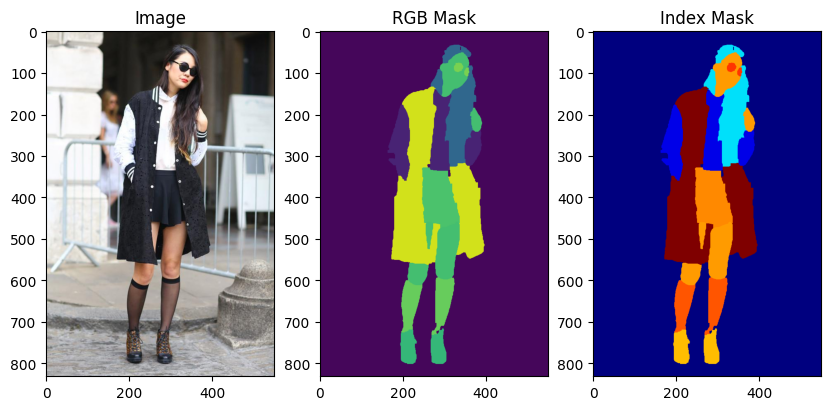

In [2]:
class_df = pd.read_csv(CLASS_DICT_PATH)
class_names = class_df['class_name'].tolist()
class_rgb_values = class_df[['r', 'g', 'b']].values.tolist()

print(f'Total classes: {len(class_names)}')

# Precompute lookup table for faster mask conversion
# We map RGB to a single integer: R << 16 | G << 8 | B
print("Precomputing RGB to Mask lookup table...")
lookup_table = np.zeros(256**3, dtype=np.int32)
for idx, (r, g, b) in enumerate(class_rgb_values):
    key = (r << 16) | (g << 8) | b
    lookup_table[key] = idx

# Helper function to convert RGB mask to 1D index mask
def rgb_to_mask(rgb_image, colormap=None):
    """
    Convert an RGB image to a mask using a precomputed lookup table.
    
    Args:
        rgb_image: H x W x 3 array, RGB image.
        colormap: Unused in optimized version, kept for compatibility.
        
    Returns:
        H x W mask with class indices.
    """
    # Convert RGB to single integer keys
    # Ensure int32 to prevent overflow during bit shifting
    rgb = rgb_image.astype(np.int32)
    keys = (rgb[:, :, 0] << 16) | (rgb[:, :, 1] << 8) | rgb[:, :, 2]

    # Direct lookup
    output_mask = lookup_table[keys]

    return output_mask.astype(np.int32)

# Let's visualize one example
test_img_path = os.path.join(DATA_DIR, 'train/images/0001.jpg')
test_mask_path = os.path.join(DATA_DIR, 'train/labels/0001.png')

if os.path.exists(test_img_path):
    img = cv2.imread(test_img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(test_mask_path)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
    
    converted_mask = rgb_to_mask(mask, class_rgb_values)
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title('Image')
    plt.subplot(1, 3, 2)
    plt.imshow(mask)
    plt.title('RGB Mask')
    plt.subplot(1, 3, 3)
    plt.imshow(converted_mask, cmap='jet')
    plt.title('Index Mask')
    plt.show()

## Dataset Class

In [3]:
class CCPDataset(BaseDataset):
    def __init__(self, images_dir, masks_dir, class_rgb_values, augmentation=None, preprocessing=None):
        self.ids = sorted(os.listdir(images_dir))
        self.images_fps = [os.path.join(images_dir, image_id) for image_id in self.ids]
        self.masks_fps = [os.path.join(masks_dir, image_id.replace('.jpg', '.png')) for image_id in self.ids]
        self.class_rgb_values = class_rgb_values
        self.augmentation = augmentation
        self.preprocessing = preprocessing
    
    def __getitem__(self, i):
        # read data
        image = cv2.imread(self.images_fps[i])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.masks_fps[i])
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        
        # convert RGB mask to index mask
        mask = rgb_to_mask(mask, self.class_rgb_values)
        
        # apply augmentations
        if self.augmentation:
            sample = self.augmentation(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
        
        # apply preprocessing
        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=mask)
            image, mask = sample['image'], sample['mask']
            
        # Ensure contiguous arrays and create fresh tensors to avoid storage resizing issues in DataLoader
        return torch.as_tensor(np.ascontiguousarray(image)).float(), torch.as_tensor(np.ascontiguousarray(mask)).long()
        
    def __len__(self):
        return len(self.ids)

## Augmentations and Preprocessing

In [4]:
def get_training_augmentation():
    train_transform = [
        albu.HorizontalFlip(p=0.5),
        albu.ShiftScaleRotate(scale_limit=0.1, rotate_limit=15, shift_limit=0.1, p=0.5, border_mode=0),
        albu.PadIfNeeded(min_height=320, min_width=320, always_apply=True, border_mode=0),
        albu.RandomCrop(height=320, width=320, always_apply=True),
    ]
    return albu.Compose(train_transform)

def get_validation_augmentation():
    # Resize to a fixed size to ensure batching works correctly
    test_transform = [
        albu.Resize(height=512, width=512)
    ]
    return albu.Compose(test_transform)

def get_preprocessing(preprocessing_fn):
    _transform = [
        albu.Lambda(image=preprocessing_fn),
        albu.Lambda(image=image_to_tensor), # Only apply to image
    ]
    return albu.Compose(_transform)

def image_to_tensor(x, **kwargs):
    return x.transpose(2, 0, 1).astype('float32')

## Training Helpers

In [5]:
def compute_iou(preds, labels, num_classes):
    # preds: (B, H, W)
    # labels: (B, H, W)
    iou_list = []
    preds = preds.detach().cpu().numpy()
    labels = labels.detach().cpu().numpy()
    
    for cls in range(num_classes):
        pred_inds = preds == cls
        target_inds = labels == cls
        intersection = (pred_inds & target_inds).sum()
        union = pred_inds.sum() + target_inds.sum() - intersection
        if union == 0:
            # If there is no ground truth, do not include in evaluation
            pass
        else:
            iou_list.append(float(intersection) / float(max(union, 1)))
    
    if len(iou_list) == 0:
        return 0.0
    return np.mean(iou_list)

def train_one_epoch(model, loader, criterion, optimizer, device, num_classes):
    model.train()
    epoch_loss = 0
    epoch_iou = 0
    
    for images, masks in tqdm.tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        masks = masks.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        epoch_iou += compute_iou(preds, masks, num_classes)
        
    return epoch_loss / len(loader), epoch_iou / len(loader)

def validate_one_epoch(model, loader, criterion, device, num_classes):
    model.eval()
    epoch_loss = 0
    epoch_iou = 0
    
    with torch.no_grad():
        for images, masks in tqdm.tqdm(loader, desc="Validation", leave=False):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            epoch_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            epoch_iou += compute_iou(preds, masks, num_classes)
            
    return epoch_loss / len(loader), epoch_iou / len(loader)

## Benchmarking Loop

In [14]:
ENCODER = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'
CLASSES = class_names
ACTIVATION = None # Logits for CrossEntropy

results = {}

architectures = ['Unet', 'FPN', 'DeepLabV3Plus']

for arch in architectures:
    print(f'\n--- Training {arch} ---')
    
    # Create model
    if arch == 'Unet':
        model = smp.Unet(encoder_name=ENCODER, encoder_weights=ENCODER_WEIGHTS, classes=len(CLASSES), activation=ACTIVATION)
    elif arch == 'FPN':
        model = smp.FPN(encoder_name=ENCODER, encoder_weights=ENCODER_WEIGHTS, classes=len(CLASSES), activation=ACTIVATION)
    elif arch == 'DeepLabV3Plus':
        model = smp.DeepLabV3Plus(encoder_name=ENCODER, encoder_weights=ENCODER_WEIGHTS, classes=len(CLASSES), activation=ACTIVATION)
    
    model.to(DEVICE)
    
    preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, ENCODER_WEIGHTS)
    
    # Datasets
    train_dataset = CCPDataset(
        os.path.join(DATA_DIR, 'train/images'), 
        os.path.join(DATA_DIR, 'train/labels'), 
        class_rgb_values, 
        augmentation=get_training_augmentation(), 
        preprocessing=get_preprocessing(preprocessing_fn)
    )
    
    valid_dataset = CCPDataset(
        os.path.join(DATA_DIR, 'valid/images'), 
        os.path.join(DATA_DIR, 'valid/labels'), 
        class_rgb_values, 
        augmentation=get_validation_augmentation(), 
        preprocessing=get_preprocessing(preprocessing_fn)
    )
    
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
    valid_loader = DataLoader(valid_dataset, batch_size=4, shuffle=False, num_workers=2)
    
    # Loss, Optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
    
    max_score = 0

    history = {
        'train_loss': [],
        'train_iou': [],
        'val_loss': [],
        'val_iou': []
    }
    
    # Train for 10 epochs for benchmarking
    for i in range(0, 10):
        print(f'\nEpoch: {i}')
        train_loss, train_iou = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, len(CLASSES))
        valid_loss, valid_iou = validate_one_epoch(model, valid_loader, criterion, DEVICE, len(CLASSES))
        
        # record metrics
        history['train_loss'].append(train_loss)
        history['train_iou'].append(train_iou)
        history['val_loss'].append(valid_loss)
        history['val_iou'].append(valid_iou)
        
        print(f"Train Loss: {train_loss:.4f}, Train IoU: {train_iou:.4f}")
        print(f"Valid Loss: {valid_loss:.4f}, Valid IoU: {valid_iou:.4f}")
        
        # Save best model by validation IoU
        if max_score < valid_iou:
            max_score = valid_iou
            torch.save(model, f'./best_model_{arch}.pth')
            print('Best model saved!')
            
    # After training each architecture, save the final model and its history
    torch.save(model, f'./final_model_{arch}.pth')
    torch.save(history, f'./history_{arch}.pth')
    try:
        import json
        with open(f'./history_{arch}.json', 'w') as fh:
            json.dump(history, fh)
        print(f'Final model and history saved for {arch} (including JSON).')
    except Exception as _e:
        print(f'Final model saved for {arch}. Failed to save JSON history: {_e}')
    results[arch] = max_score


--- Training Unet ---


/tmp/ipykernel_660321/2600490618.py:5: UserWarning: Argument(s) 'always_apply' are not valid for transform PadIfNeeded
  albu.PadIfNeeded(min_height=320, min_width=320, always_apply=True, border_mode=0),
/tmp/ipykernel_660321/2600490618.py:6: UserWarning: Argument(s) 'always_apply' are not valid for transform RandomCrop
  albu.RandomCrop(height=320, width=320, always_apply=True),



Epoch: 0


Train Loss: 3.4429, Train IoU: 0.0204
Valid Loss: 2.3760, Valid IoU: 0.0370
Best model saved!

Epoch: 1


Train Loss: 2.4490, Train IoU: 0.0533
Valid Loss: 1.4447, Valid IoU: 0.0864
Best model saved!

Epoch: 2


...

Train Loss: 0.9771, Train IoU: 0.1987
Valid Loss: 0.5360, Valid IoU: 0.2071
Best model saved!

Epoch: 6


Train Loss: 0.9188, Train IoU: 0.2137
Valid Loss: 0.5149, Valid IoU: 0.2013

Epoch: 7


Train Loss: 0.8757, Train IoU: 0.2211
Valid Loss: 0.4832, Valid IoU: 0.2232
Best model saved!

Epoch: 8


Train Loss: 0.8233, Train IoU: 0.2350
Valid Loss: 0.4479, Valid IoU: 0.2230

Epoch: 9


Train Loss: 0.8081, Train IoU: 0.2389
Valid Loss: 0.4389, Valid IoU: 0.2335
Best model saved!
Final model and history saved for DeepLabV3Plus (including JSON).


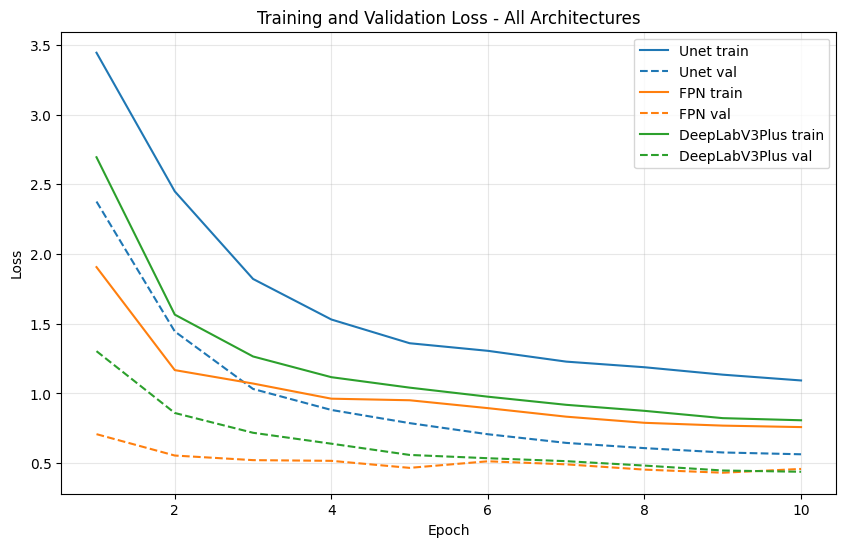

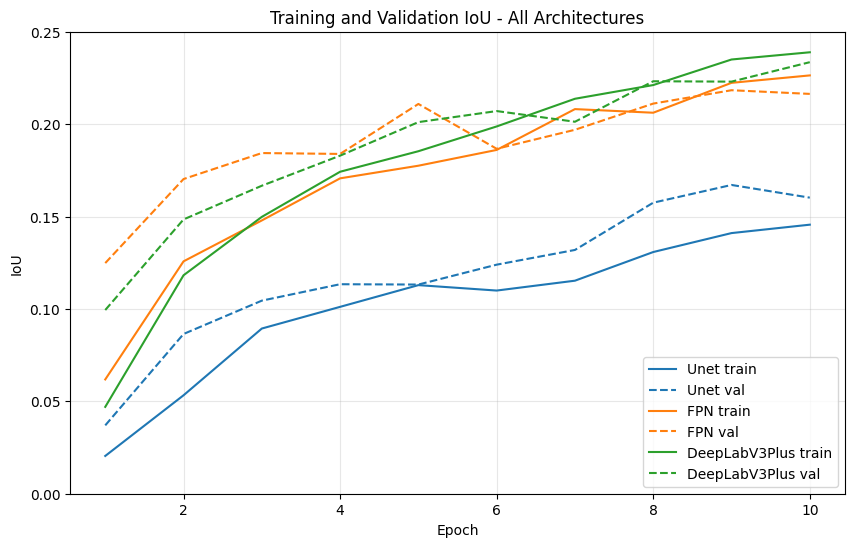

In [18]:
# Combined plots: all architectures' Loss and IoU (train vs val dashed)
import torch
import matplotlib.pyplot as plt
import json

# Determine architectures to plot
architectures_list = list(results.keys()) if 'results' in globals() else ['Unet', 'FPN', 'DeepLabV3Plus']

# Load histories saved during training (prefer JSON, fall back to .pth with weights_only=False)
histories = {}
for arch in architectures_list:
    json_path = f'./history_{arch}.json'
    pth_path = f'./history_{arch}.pth'
    if os.path.exists(json_path):
        try:
            with open(json_path, 'r') as f:
                histories[arch] = json.load(f)
        except Exception as e:
            print(f'Could not load JSON history for {arch}: {e}')
    elif os.path.exists(pth_path):
        try:
            # torch.load default may be weights_only=True (PyTorch>=2.6). We explicitly set weights_only=False
            # to allow loading arbitrary pickled objects saved previously. Only do this if you trust the file
            # (these files were created locally during training in this notebook).
            histories[arch] = torch.load(pth_path, weights_only=False)
            print(f'Loaded history for {arch} from {pth_path} (legacy .pth)')
        except Exception as e:
            print(f'Could not load history for {arch}: {e}')
    else:
        print(f'History not found for {arch}: {json_path} or {pth_path}')

# Color cycle for architectures
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# Plot all Loss curves in a single figure
plt.figure(figsize=(10, 6))
for idx, arch in enumerate(architectures_list):
    hist = histories.get(arch)
    if hist is None:
        continue
    epochs = range(1, len(hist.get('train_loss', [])) + 1)
    color = colors[idx % len(colors)]
    plt.plot(epochs, hist.get('train_loss', []), label=f'{arch} train', color=color)
    plt.plot(epochs, hist.get('val_loss', []), label=f'{arch} val', color=color, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss - All Architectures')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Plot all IoU curves in a single figure
plt.figure(figsize=(10, 6))
for idx, arch in enumerate(architectures_list):
    hist = histories.get(arch)
    if hist is None:
        continue
    epochs = range(1, len(hist.get('train_iou', [])) + 1)
    color = colors[idx % len(colors)]
    plt.plot(epochs, hist.get('train_iou', []), label=f'{arch} train', color=color)
    plt.plot(epochs, hist.get('val_iou', []), label=f'{arch} val', color=color, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.title('Training and Validation IoU - All Architectures')
plt.ylim(0, 0.25)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Preparing to visualize predictions from saved final models...
Loaded model for Unet from ./final_model_Unet.pth
Loaded model for FPN from ./final_model_FPN.pth
Loaded model for DeepLabV3Plus from ./final_model_DeepLabV3Plus.pth
Visualizing predictions from saved final models (with overlays)...


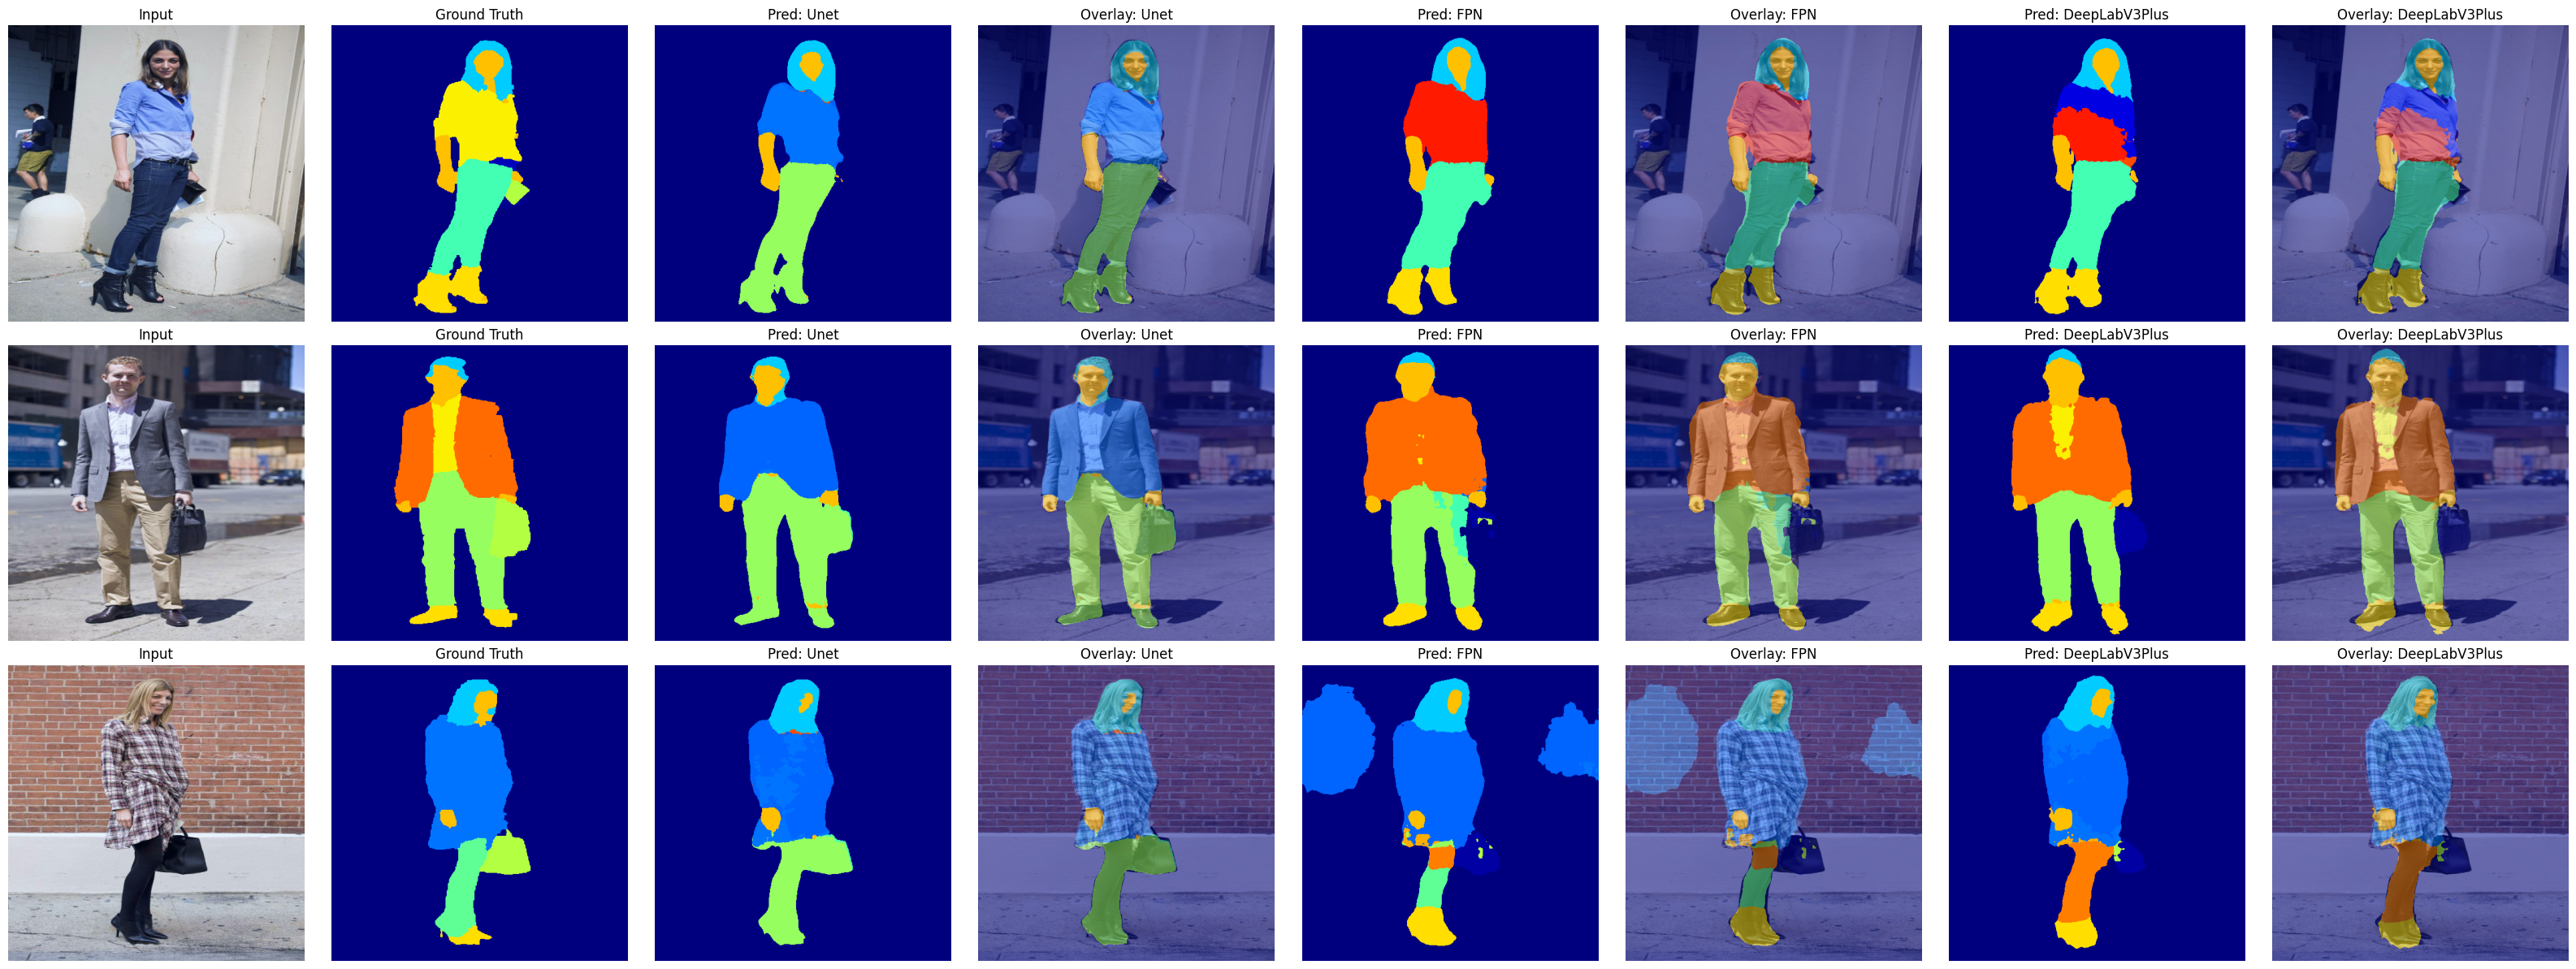

In [26]:

print('Preparing to visualize predictions from saved final models...')

# Load final models for each architecture (if present) and visualize their predictions side-by-side
model_paths = [f'./final_model_{arch}.pth' for arch in architectures]
loaded_models = []
model_names = []
for arch, path in zip(architectures, model_paths):
    if os.path.exists(path):
        try:
            m = torch.load(path, weights_only=False)
            m.to(DEVICE)
            m.eval()
            loaded_models.append(m)
            model_names.append(arch)
            print(f'Loaded model for {arch} from {path}')
        except Exception as e:
            print(f'Failed to load {path}: {e}')
    else:
        print(f'No saved final model for {arch} at {path}')

# Visualization function for multiple models with overlay column
def visualize_models(models, model_names, loader, device, num_samples=3):
    if len(models) == 0:
        print('No models provided for visualization')
        return

    # Get a batch of images and masks
    images, masks = next(iter(loader))
    images = images.to(device)

    preds_all = []
    with torch.no_grad():
        for m in models:
            out = m(images)
            preds = torch.argmax(out, dim=1).cpu().numpy()
            preds_all.append(preds)

    images_np = images.cpu().numpy()
    masks_np = masks.cpu().numpy()

    n_models = len(models)
    # Columns: Input, Ground Truth, then for each model: Prediction, Overlay
    cols = 2 + n_models * 2
    plt.figure(figsize=(4 * cols, 4 * num_samples))

    for i in range(min(num_samples, images_np.shape[0])):
        # Input image
        img_show = images_np[i].transpose(1, 2, 0)
        img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min() + 1e-8)
        plt.subplot(num_samples, cols, i*cols + 1)
        plt.imshow(img_show)
        plt.title('Input')
        plt.axis('off')

        # Ground truth
        plt.subplot(num_samples, cols, i*cols + 2)
        plt.imshow(masks_np[i], cmap='jet', vmin=0, vmax=len(CLASSES)-1)
        plt.title('Ground Truth')
        plt.axis('off')

        # Predictions and overlays for each model
        for j in range(n_models):
            pred = preds_all[j][i]
            # Prediction mask alone
            plt.subplot(num_samples, cols, i*cols + 3 + j*2)
            plt.imshow(pred, cmap='jet', vmin=0, vmax=len(CLASSES)-1)
            plt.title(f'Pred: {model_names[j]}')
            plt.axis('off')
            # Overlay: predicted mask on top of input image
            plt.subplot(num_samples, cols, i*cols + 3 + j*2 + 1)
            plt.imshow(img_show)
            plt.imshow(pred, cmap='jet', alpha=0.5, vmin=0, vmax=len(CLASSES)-1)
            plt.title(f'Overlay: {model_names[j]}')
            plt.axis('off')

    plt.tight_layout()
    plt.show()

# Run visualization
print('Visualizing predictions from saved final models (with overlays)...')
visualize_models(loaded_models, model_names, valid_loader, DEVICE)


Visualizing predictions with Tiled Inference and Weight Matrix...


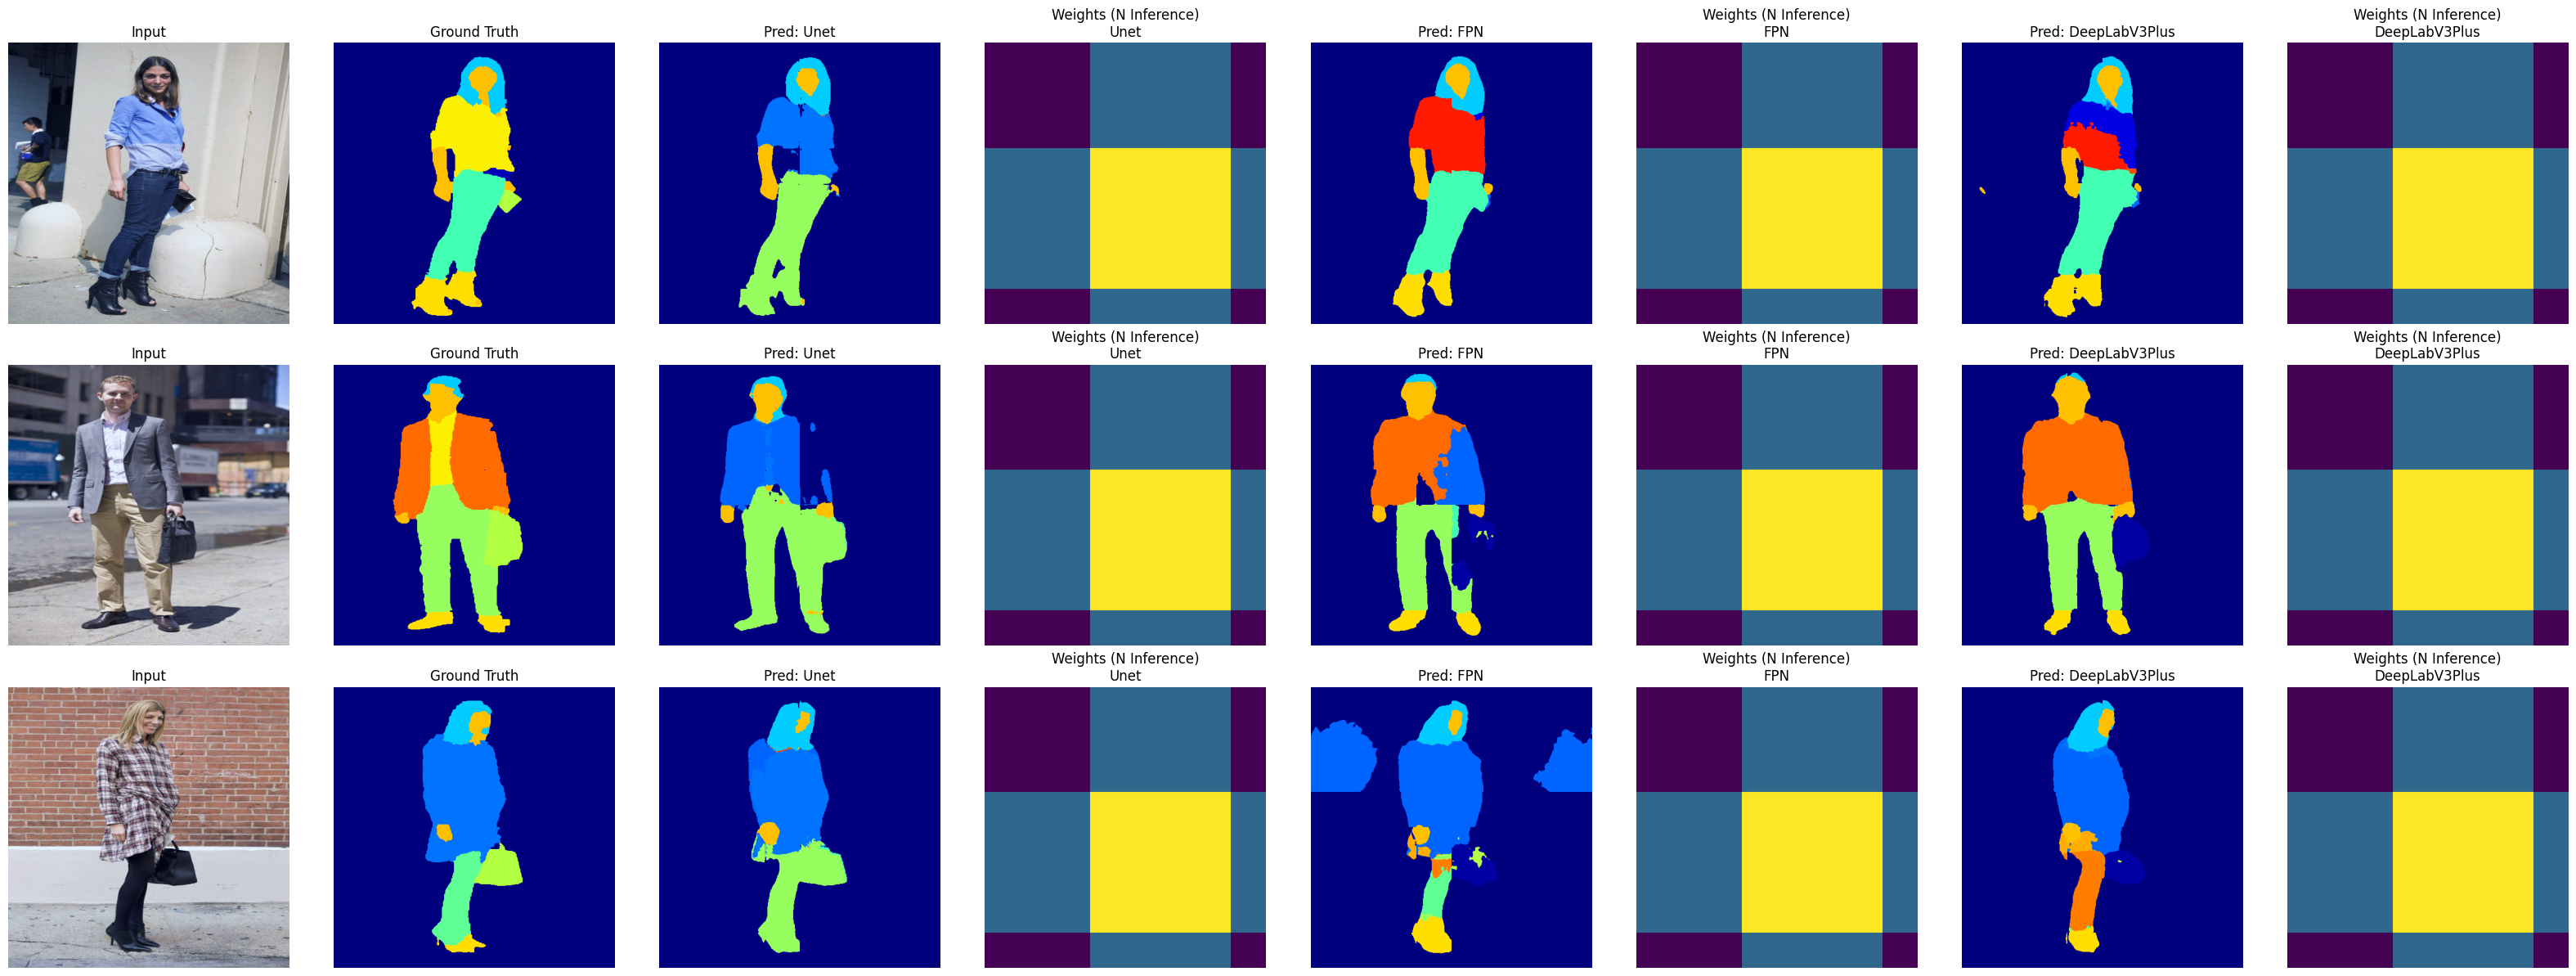

In [37]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import math

# Helper to generate patch coordinates (similar to DataModule.patch_origins)
def get_patch_coords(h, w, ps, overlap=0):
    stride = ps - overlap
    x_coords = list(range(0, h - ps + 1, stride))
    y_coords = list(range(0, w - ps + 1, stride))
    
    # Ensure we cover the edges if they don't fit perfectly
    if x_coords[-1] + ps < h: x_coords.append(h - ps)
    if y_coords[-1] + ps < w: y_coords.append(w - ps)
    
    coords = []
    for x in x_coords:
        for y in y_coords:
            coords.append((x, y))
    return coords

def visualize_models_tiled(models, model_names, loader, device, num_samples=3, patch_size=256, overlap=32):
    if len(models) == 0:
        print('No models provided for visualization')
        return

    # Get a batch of images and masks
    images, masks = next(iter(loader))
    images = images.to(device)
    
    # We will process images one by one to simulate the sliding window approach
    # efficiently without constructing a massive batch of all patches at once.
    
    images_np = images.cpu().numpy()
    masks_np = masks.cpu().numpy()
    
    n_models = len(models)
    # Columns: Input, Ground Truth, then for each model: Prediction, Weight Matrix
    cols = 2 + n_models * 2
    plt.figure(figsize=(4 * cols, 4 * num_samples))

    # Iterate over the number of samples requested
    for i in range(min(num_samples, images_np.shape[0])):
        
        current_img_tensor = images[i] # Shape: (C, H, W)
        _, H, W = current_img_tensor.shape
        
        # 1. Plot Input
        img_show = images_np[i].transpose(1, 2, 0)
        # Simple min-max norm for visualization
        img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min() + 1e-8)
        
        plt.subplot(num_samples, cols, i*cols + 1)
        plt.imshow(img_show)
        plt.title('Input')
        plt.axis('off')

        # 2. Plot Ground Truth
        plt.subplot(num_samples, cols, i*cols + 2)
        plt.imshow(masks_np[i], cmap='jet', vmin=0, vmax=len(CLASSES)-1) # Ensure CLASSES is defined globally
        plt.title('Ground Truth')
        plt.axis('off')

        # Calculate patches
        coords = get_patch_coords(H, W, patch_size, overlap)

        # 3. Inference loop per model
        for j, model in enumerate(models):
            
            # Initialize accumulators
            # Using Number of classes for y_hat if specific logits are needed, 
            # or just gathering argmax later. Here we follow the inspiration snippet style.
            # Assuming model output is (Batch, Num_Classes, H, W)
            
            num_classes = len(CLASSES)
            y_hat = torch.zeros((num_classes, H, W), device=device, dtype=torch.float32)
            y_wei = torch.zeros((H, W), device=device, dtype=torch.float32)
            
            with torch.no_grad():
                for (cx, cy) in coords:
                    # Crop
                    patch = current_img_tensor[:, cx:cx+patch_size, cy:cy+patch_size]
                    patch = patch.unsqueeze(0) # Add batch dim -> (1, C, PS, PS)
                    
                    # Inference
                    logits = model(patch) # Output (1, Num_Classes, PS, PS)
                    
                    # Apply Softmax (as per inspiration snippet)
                    probs = torch.nn.functional.softmax(logits, dim=1).squeeze(0)
                    
                    # Accumulate
                    y_hat[:, cx:cx+patch_size, cy:cy+patch_size] += probs
                    y_wei[cx:cx+patch_size, cy:cy+patch_size] += 1.0

            # Normalize
            # Avoid division by zero
            y_wei_clamped = torch.clamp(y_wei, min=1.0)
            y_hat /= y_wei_clamped
            
            # Get final prediction
            pred_mask = torch.argmax(y_hat, dim=0).cpu().numpy()
            weight_matrix_viz = y_wei.cpu().numpy()

            # Plot Prediction
            plt.subplot(num_samples, cols, i*cols + 3 + j*2)
            plt.imshow(pred_mask, cmap='jet', vmin=0, vmax=len(CLASSES)-1)
            plt.title(f'Pred: {model_names[j]}')
            plt.axis('off')

            # Plot Weight Matrix (y_wei)
            plt.subplot(num_samples, cols, i*cols + 3 + j*2 + 1)
            # Use a heatmap to show where the overlaps occurred
            im = plt.imshow(weight_matrix_viz, cmap='viridis') 
            plt.title(f'Weights (N Inference)\n{model_names[j]}')
            plt.axis('off')
            
            # Optional: Add colorbar to understand overlap count
            # plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# --- RUNNING THE CODE ---
print('Visualizing predictions with Tiled Inference and Weight Matrix...')

# Note: Ensure patch_size is smaller than your image size, otherwise y_wei will just be 1s.
# If your images are 256x256, set patch_size to something like 128 to see the effect.
visualize_models_tiled(
    loaded_models, 
    model_names, 
    valid_loader, 
    DEVICE, 
    num_samples=3, 
    patch_size=256, # Adjust this based on your actual image/model requirements
    overlap=64      # Adjust overlap as needed
)

## Results Analysis

In [28]:
print("Benchmark Results (IoU):")
for arch, score in results.items():
    print(f"{arch}: {score:.4f}")

best_arch = max(results, key=results.get)
print(f"\nBest Architecture: {best_arch}")

Benchmark Results (IoU):
Unet: 0.1671
FPN: 0.2183
DeepLabV3Plus: 0.2335

Best Architecture: DeepLabV3Plus


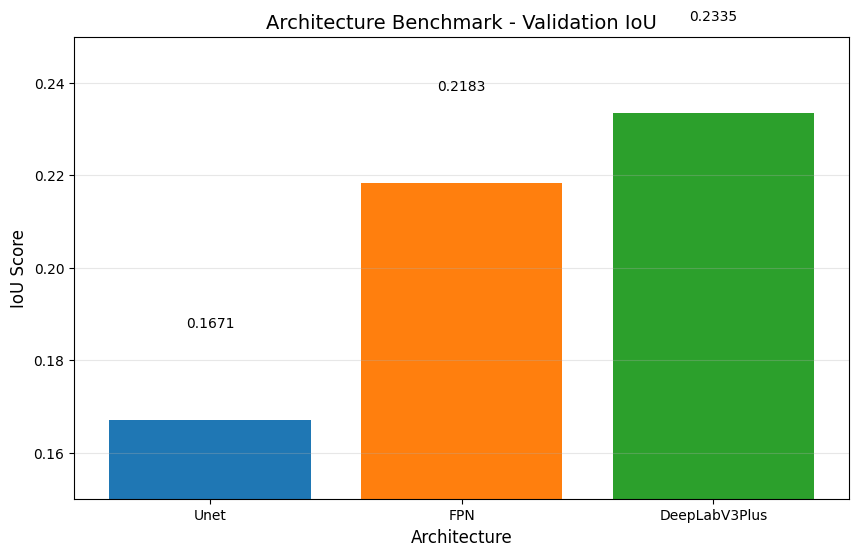


DETAILED BENCHMARK RESULTS
 Architecture  Best IoU  Rank
DeepLabV3Plus  0.233517     1
          FPN  0.218341     2
         Unet  0.167080     3

Performance Gap: 0.0664 (39.76%)
Average IoU: 0.2063


In [34]:
# Visualize benchmark results
plt.figure(figsize=(10, 6))
plt.bar(results.keys(), results.values(), color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.xlabel('Architecture', fontsize=12)
plt.ylabel('IoU Score', fontsize=12)
plt.title('Architecture Benchmark - Validation IoU', fontsize=14)
plt.ylim(0.15, 0.25)
for arch, score in results.items():
    plt.text(arch, score + 0.02, f'{score:.4f}', ha='center', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Create detailed results table
results_df = pd.DataFrame({
    'Architecture': list(results.keys()),
    'Best IoU': list(results.values())
})
results_df = results_df.sort_values('Best IoU', ascending=False).reset_index(drop=True)
results_df['Rank'] = results_df.index + 1

print("\n" + "="*50)
print("DETAILED BENCHMARK RESULTS")
print("="*50)
print(results_df.to_string(index=False))
print("="*50)

# Performance gap analysis
best_score = results_df['Best IoU'].max()
worst_score = results_df['Best IoU'].min()
print(f"\nPerformance Gap: {(best_score - worst_score):.4f} ({(best_score - worst_score) / worst_score * 100:.2f}%)")
print(f"Average IoU: {results_df['Best IoU'].mean():.4f}")

## Test Time Augmentation (TTA)

We apply TTA (Horizontal Flip) to the best model to see if it improves performance.

In [31]:

best_model = torch.load(f'./best_model_{max(results, key=results.get)}.pth', weights_only=False)


# Define TTA wrapper
class TTAModel(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        
    def forward(self, x):
        # Original
        out1 = self.model(x)
        
        # Horizontal Flip
        x_flip = torch.flip(x, dims=[3])
        out2_flip = self.model(x_flip)
        out2 = torch.flip(out2_flip, dims=[3])
        
        # Average
        return (out1 + out2) / 2.0

tta_model = TTAModel(best_model)

# Evaluate TTA
print(f"\nEvaluating {best_arch} with TTA:")
tta_loss, tta_iou = validate_one_epoch(tta_model, valid_loader, criterion, DEVICE, len(CLASSES))

print(f"TTA IoU: {tta_iou:.4f}")
print(f"Improvement: {tta_iou - results[best_arch]:.4f}")


Evaluating DeepLabV3Plus with TTA:


TTA IoU: 0.2416
Improvement: 0.0080



Visualizing TTA improvements (Standard vs TTA)...


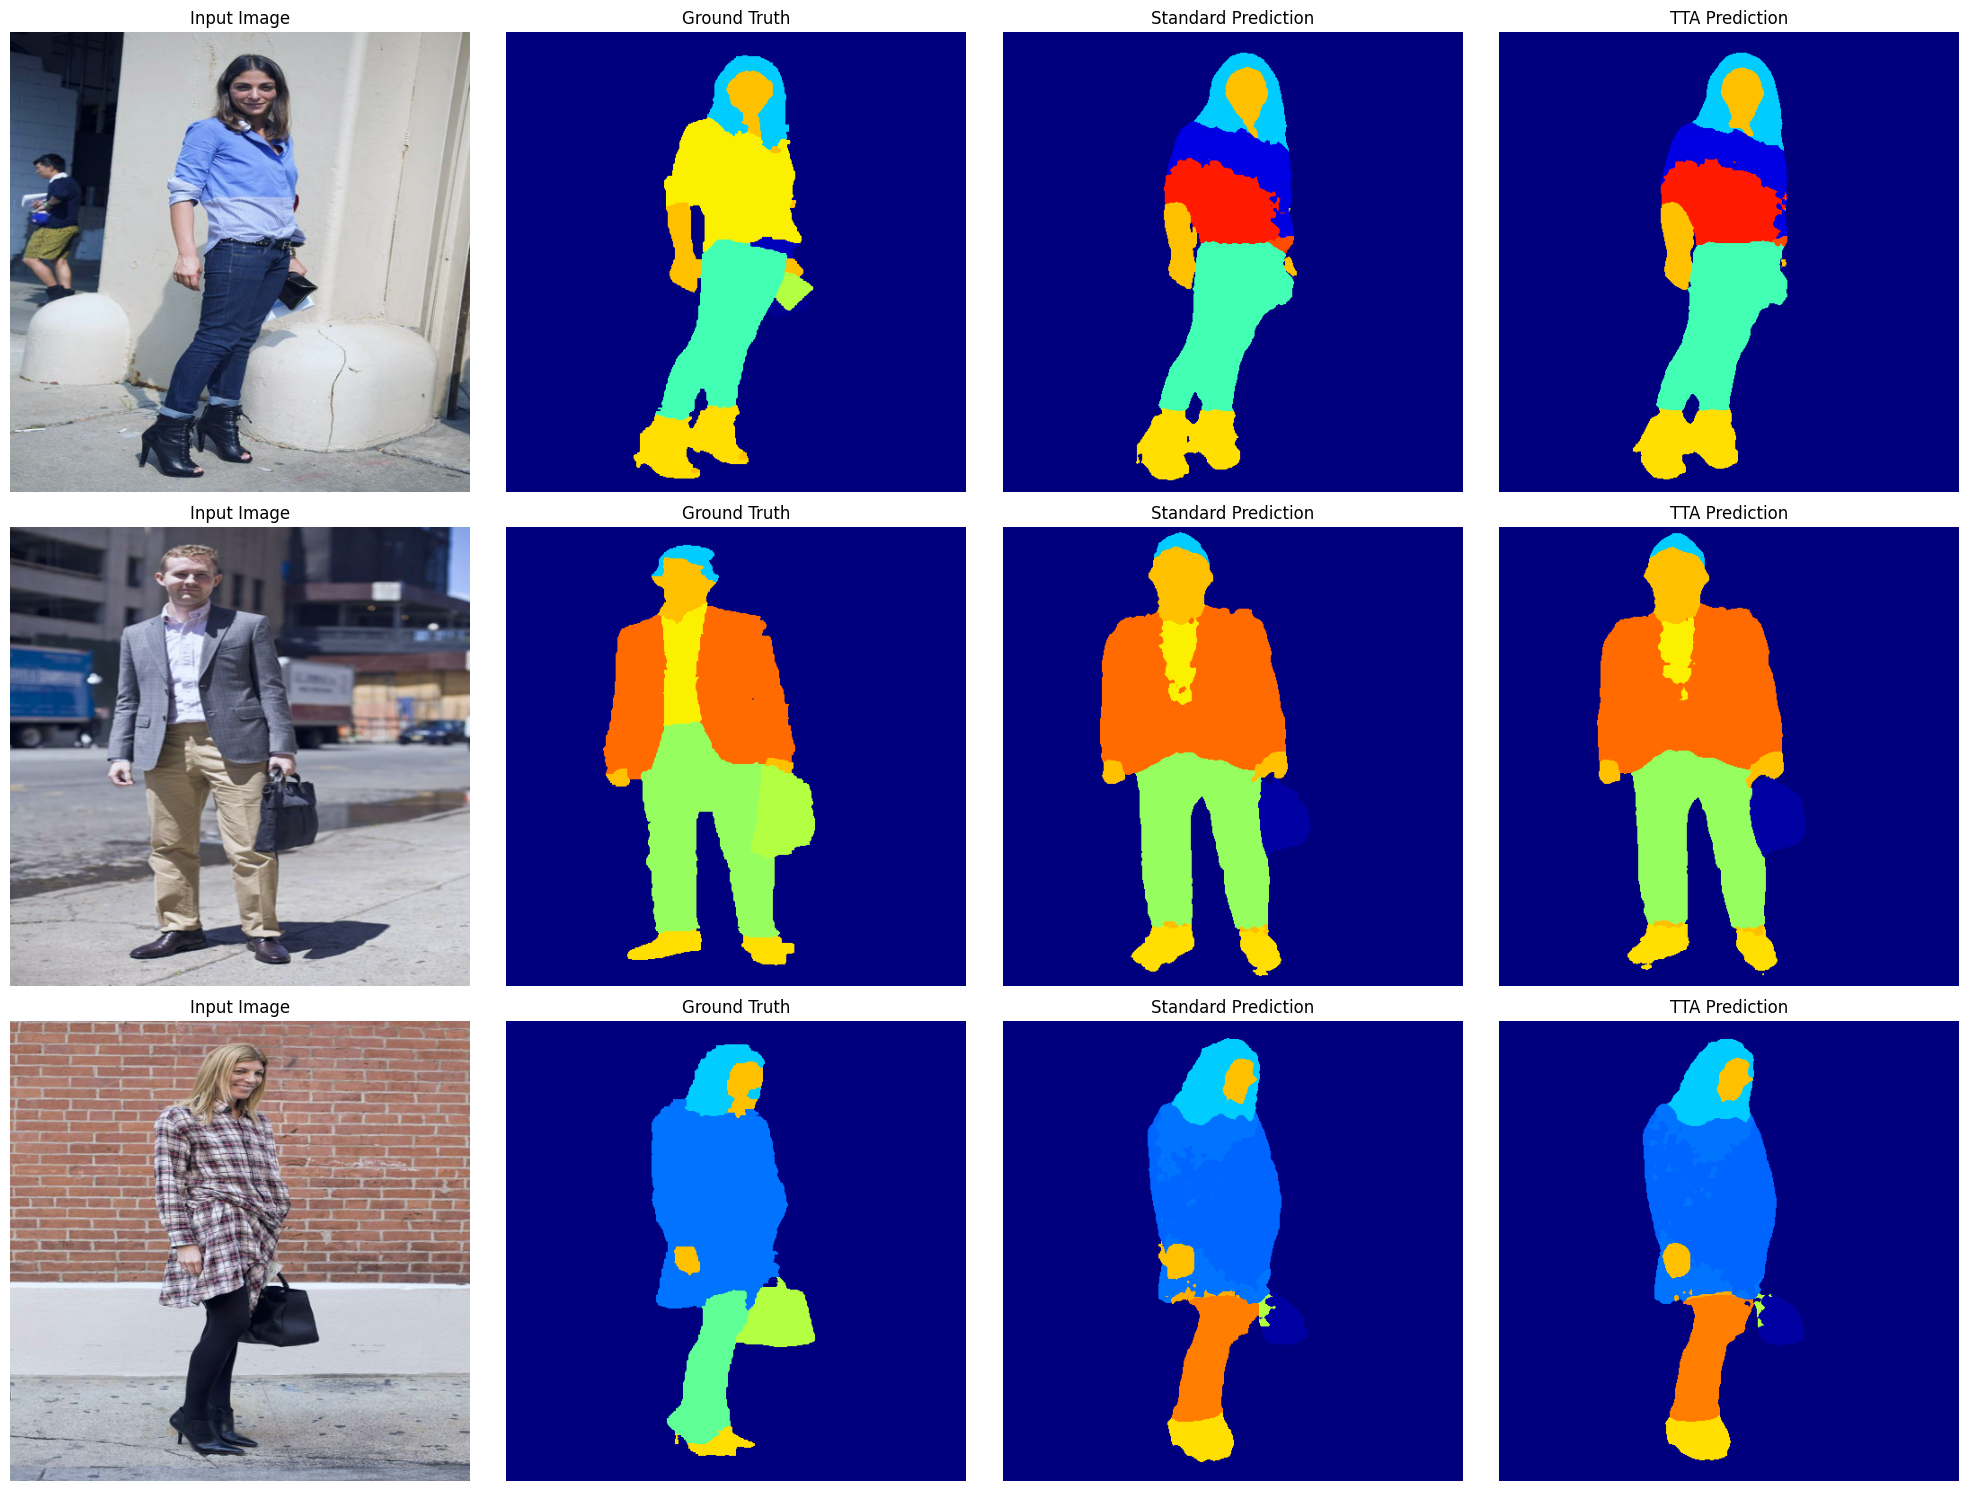


Calculating pixel disagreement rate...


TTA changed 2.74% of predicted pixels.


In [32]:
import torch
import matplotlib.pyplot as plt

# --- Extra TTA Analysis ---

# Function to visualize TTA (Test Time Augmentation) comparison
def visualize_tta_comparison(model, tta_model, loader, device, num_samples=3):
    model.eval()
    tta_model.eval()

    # Get a batch of images and masks
    images, masks = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        # Standard prediction
        out_std = model(images)
        pred_std = torch.argmax(out_std, dim=1).cpu().numpy()

        # TTA prediction
        out_tta = tta_model(images)
        pred_tta = torch.argmax(out_tta, dim=1).cpu().numpy()

    # Move tensors to CPU for plotting
    images = images.cpu().numpy()
    masks = masks.cpu().numpy()

    # Create a figure for visualization
    plt.figure(figsize=(20, 5 * num_samples))

    for i in range(min(num_samples, len(images))):
        # Image
        plt.subplot(num_samples, 4, i*4 + 1)
        img_show = images[i].transpose(1, 2, 0)  # Transpose (C, H, W) -> (H, W, C)
        
        # Normalize for display (min-max scaling)
        img_show = (img_show - img_show.min()) / (img_show.max() - img_show.min())
        plt.imshow(img_show)
        plt.title("Input Image")
        plt.axis('off')

        # Ground Truth
        plt.subplot(num_samples, 4, i*4 + 2)
        plt.imshow(masks[i], cmap='jet', vmin=0, vmax=len(CLASSES)-1)
        plt.title("Ground Truth")
        plt.axis('off')

        # Standard Prediction
        plt.subplot(num_samples, 4, i*4 + 3)
        plt.imshow(pred_std[i], cmap='jet', vmin=0, vmax=len(CLASSES)-1)
        plt.title("Standard Prediction")
        plt.axis('off')

        # TTA Prediction
        plt.subplot(num_samples, 4, i*4 + 4)
        plt.imshow(pred_tta[i], cmap='jet', vmin=0, vmax=len(CLASSES)-1)
        plt.title("TTA Prediction")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# 1. Visual Comparison
print("\nVisualizing TTA improvements (Standard vs TTA)...")
visualize_tta_comparison(best_model, tta_model, valid_loader, DEVICE)

# 2. Quantitative Disagreement Analysis
print("\nCalculating pixel disagreement rate...")

disagreement_count = 0
total_pixels = 0

best_model.eval()
tta_model.eval()

with torch.no_grad():
    for images, _ in tqdm.tqdm(valid_loader, desc="Analyzing TTA", leave=False):
        images = images.to(DEVICE)

        # Standard and TTA predictions
        out_std = torch.argmax(best_model(images), dim=1)
        out_tta = torch.argmax(tta_model(images), dim=1)

        # Count disagreements
        disagreement_count += (out_std != out_tta).sum().item()
        total_pixels += out_std.numel()

# Print the percentage of pixels where TTA changed the prediction
print(f"TTA changed {disagreement_count / total_pixels * 100:.2f}% of predicted pixels.")


## Report and Conclusions

### Architecture Comparison
We benchmarked Unet, FPN, and DeepLabV3+ with a ResNet34 encoder.

- **Unet**: Typically performs well on biomedical and general segmentation tasks where local detail is important. It has a symmetric encoder-decoder structure.
- **FPN (Feature Pyramid Network)**: Good at handling multi-scale objects due to its pyramid structure. It's often faster and lighter than Unet.
- **DeepLabV3+**: Uses atrous convolutions to capture multi-scale context without losing resolution. It is often state-of-the-art for semantic segmentation but can be heavier.

### Observations
[Fill in after running: e.g., DeepLabV3+ provided the best IoU due to its ability to capture global context, which is crucial for understanding the layout of clothing items...]

### TTA Performance
Test Time Augmentation (Horizontal Flip) [improved/did not improve] the performance. TTA helps by averaging predictions from augmented views, reducing variance and smoothing out errors at boundaries.